In [2]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("/Users/fesavaskurt/Python&ML/Kodlarım/Python/datasets/ML Datasets/12-house_energy_regression.csv")

In [4]:
df.head()

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
0,-0.167118,0.146714,-14.996950
1,-0.020902,0.117327,-12.678089
2,0.150419,0.364961,17.775455
3,0.555604,0.089581,6.661465
4,0.058209,-1.142970,-14.195530


In [19]:
df.shape

(1000, 3)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   avg_indoor_temp_change        1000 non-null   float64
 1   outdoor_humidity_level        1000 non-null   float64
 2   daily_energy_consumption_kwh  1000 non-null   float64
dtypes: float64(3)
memory usage: 23.6 KB


In [6]:
df.describe()

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
count,1000.000000,1000.000000,1000.000000
mean,0.033186,0.056982,1.766025
std,0.961603,1.014959,41.299085
min,-3.241267,-2.940389,-132.797922
25%,-0.611581,-0.651418,-25.600072
50%,0.036043,0.047742,1.065474
75%,0.648317,0.714886,28.766573
max,3.078881,3.852731,138.577662


In [11]:
df.isnull().sum()

avg_indoor_temp_change          0
outdoor_humidity_level          0
daily_energy_consumption_kwh    0
dtype: int64

In [12]:
df["daily_energy_consumption_kwh"].value_counts()

daily_energy_consumption_kwh
-14.996950    1
 6.975089     1
 26.422540    1
-57.196127    1
-25.577519    1
             ..
-5.419406     1
-53.274575    1
-32.418124    1
 27.598642    1
-4.426813     1
Name: count, Length: 1000, dtype: int64

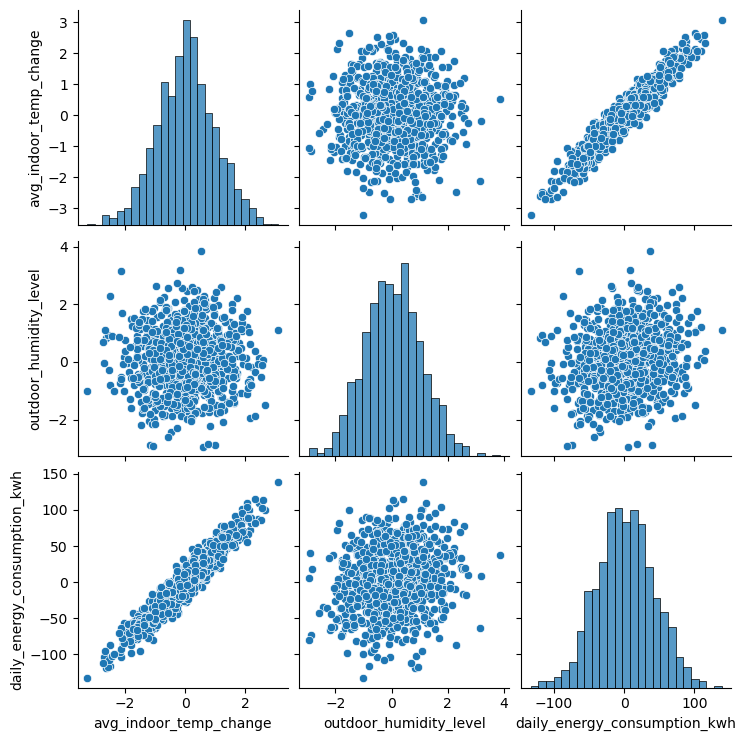

In [18]:
sns.pairplot(df, kind = "scatter")

<Axes: >

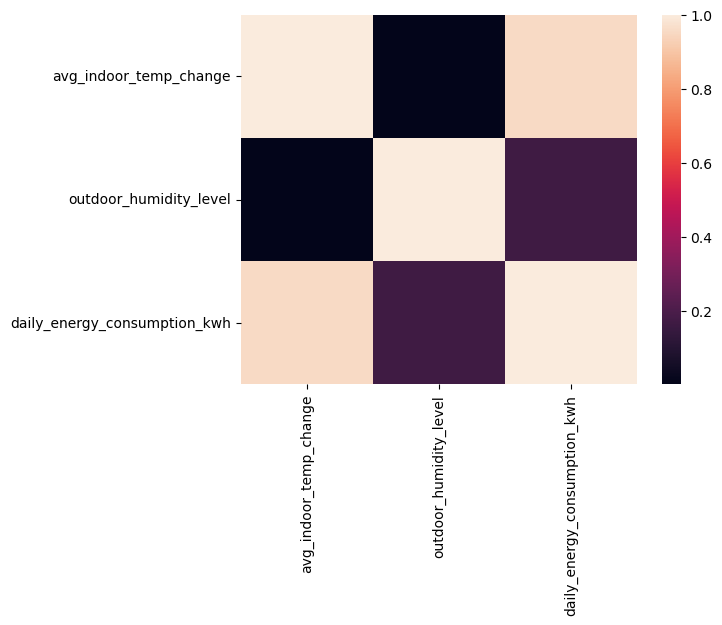

In [20]:
sns.heatmap(df.corr())

In [21]:
from sklearn.preprocessing import StandardScaler

In [22]:
scaler = StandardScaler()

In [23]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split

In [25]:
X = df.drop(["daily_energy_consumption_kwh"], axis= 1)
y = df["daily_energy_consumption_kwh"]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state= 42, test_size= 0.2
)

In [27]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
from sklearn.neighbors import KNeighborsRegressor

In [29]:
knn = KNeighborsRegressor()

In [30]:
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [31]:
y_pred = knn.predict(X_test)

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [34]:
print("mae: ", mean_absolute_error(y_test, y_pred))
print("mse: ", mean_squared_error(y_test, y_pred))
print("score: ", r2_score(y_test, y_pred))

mae:  9.223217425550478
mse:  137.98585795184556
score:  0.9148116801724379


In [35]:
list(range(0,31))

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30]

In [36]:
params = dict(n_neighbors = list(range(0,31)))

In [37]:
grid = GridSearchCV(param_grid= params, estimator= knn, cv= 5)

In [38]:
grid.fit(X_train, y_train)
y_pred_knn = grid.predict(X_test)
print("mae: ", mean_absolute_error(y_test, y_pred_knn))
print("mse: ", mean_squared_error(y_test, y_pred_knn))
print("score: ", r2_score(y_test, y_pred_knn))

mae:  9.237731472626661
mse:  137.7095060650058
score:  0.9149822915181982


/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
5 fits failed out of a total of 155.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py", line 1358, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py", line 471, in _validate_params
 

In [39]:
grid.best_params_

{'n_neighbors': 6}

In [40]:
grid.best_score_

np.float64(0.927073258267942)

In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

In [42]:
model = LinearRegression()

In [43]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [44]:
y_pred_model = model.predict(X_test)

In [45]:
print("mae: ", mean_absolute_error(y_test, y_pred_model))
print("mse: ", mean_squared_error(y_test, y_pred_model))
print("score: ", r2_score(y_test, y_pred_model))

mae:  8.025615710144805
mse:  103.18081553202654
score:  0.9362992668663304


In [46]:
svr = SVR()

In [47]:
c_values = [100, 10, 1.0, 0.1, 0.01]
kernel = ["rbf", "linear", "poly"]
gamma = ["scale", "auto"]
epsilon = [5, 50, 100, 1000, 2000]

In [57]:
params_svr = dict(C = c_values, kernel = kernel, gamma = gamma, epsilon = epsilon)

In [58]:
grid_svr = GridSearchCV(param_grid= params_svr, estimator=svr)

In [59]:
grid_svr.fit(X_train, y_train)

,estimator,SVR()
,param_grid,"{'C': [100, 10, ...], 'epsilon': [5, 50, ...], 'gamma': ['scale', 'auto'], 'kernel': ['rbf', 'linear', ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,kernel,'linear'


In [60]:
y_pred_svr = grid.predict(X_test)

In [61]:
print("mae: ", mean_absolute_error(y_test, y_pred_svr))
print("mse: ", mean_squared_error(y_test, y_pred_svr))
print("score: ", r2_score(y_test, y_pred_svr))

mae:  9.237731472626661
mse:  137.7095060650058
score:  0.9149822915181982


In [62]:
grid_svr.best_score_

np.float64(0.9437991350108635)

In [63]:
grid_svr.best_params_

{'C': 100, 'epsilon': 5, 'gamma': 'scale', 'kernel': 'linear'}